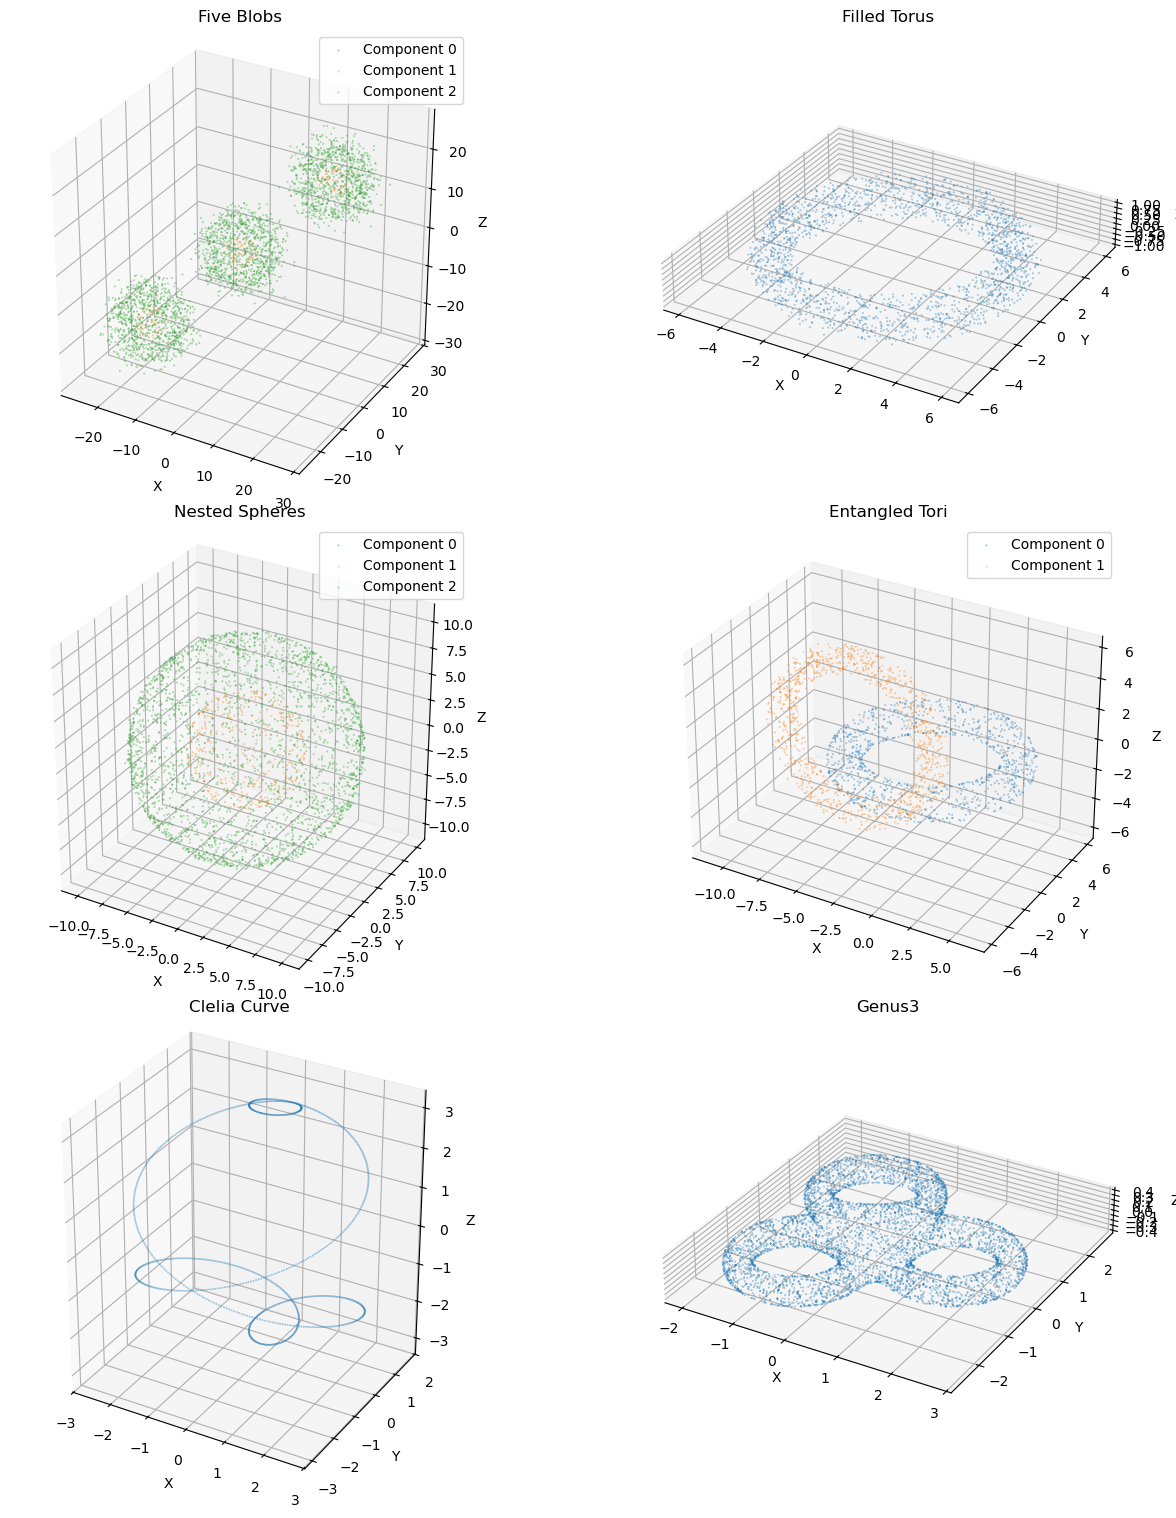

In [9]:
import torch
from skimage.measure import marching_cubes
import numpy as np
import matplotlib.pyplot as plt
from geomstats.geometry.special_orthogonal import SpecialOrthogonal  # noqa: E402


def generate_three_manifolds(manifold, n_points_per_manifold=1000, noise_var=0.2, embedding_dim=3, translations=None,
                             rotations=None):
    if translations is None:
        translations = [
            15 * torch.ones(embedding_dim),
            -15 * torch.ones(embedding_dim),
            torch.zeros(embedding_dim),
        ]

    if rotations is None:
        rotations = [
            SpecialOrthogonal(n=embedding_dim).random_point(),
            SpecialOrthogonal(n=embedding_dim).random_point(),
            SpecialOrthogonal(n=embedding_dim).random_point(),
        ]
    if manifold == "entangled_tori":
        points1, labels1 = generate_entangled_tori(n_points_per_manifold, filled1=True, filled2=True,
                                                   noise_var=noise_var,
                                                   embedding_dim=embedding_dim, translation=translations[0],
                                                   rotation=rotations[0])
        points2, labels2 = generate_entangled_tori(n_points_per_manifold, filled1=True, filled2=False,
                                                   noise_var=noise_var,
                                                   embedding_dim=embedding_dim, translation=translations[1],
                                                   rotation=rotations[1])
        points3, labels3 = generate_entangled_tori(n_points_per_manifold, filled1=True, filled2=False,
                                                   noise_var=noise_var,
                                                   embedding_dim=embedding_dim,
                                                   translation=translations[2], rotation=rotations[2])

    elif manifold == "nested_spheres":
        points1, labels1 = generate_nested_spheres(n_points_per_manifold, noise_var=noise_var,
                                                   embedding_dim=embedding_dim,
                                                   translation=translations[0], rotation=rotations[0])
        points2, labels2 = generate_nested_spheres(n_points_per_manifold, noise_var=noise_var,
                                                   embedding_dim=embedding_dim,
                                                   translation=translations[1], rotation=rotations[1])
        points3, labels3 = generate_nested_spheres(n_points_per_manifold, noise_var=noise_var,
                                                   embedding_dim=embedding_dim,
                                                   translation=translations[2], rotation=rotations[2])

    elif manifold == "spheres":
        points1, labels1 = generate_sphere(n_points_per_manifold, noise_var=noise_var, filled=True,
                                           embedding_dim=embedding_dim,
                                           translation=translations[0], rotation=rotations[0])
        points2, labels2 = generate_sphere(n_points_per_manifold, noise_var=noise_var, filled=True,
                                           embedding_dim=embedding_dim,
                                           translation=translations[1], rotation=rotations[1])
        points3, labels3 = generate_sphere(n_points_per_manifold, noise_var=noise_var, filled=False,
                                           embedding_dim=embedding_dim,
                                           translation=translations[2], rotation=rotations[2])

    else:
        raise NotImplementedError(manifold)

    data = torch.cat((points1, points2, points3), dim=0)
    labels = torch.cat((labels1, labels2, labels3), dim=0)

    return data, labels


def generate_torus(n_points=5000, R=5.0, r=1.0, filled=False, noise_var=0.01, embedding_dim=3, translation=None,
                   rotation=None):
    if filled:
        theta = 2 * torch.pi * torch.rand(n_points)
        phi = 2 * torch.pi * torch.rand(n_points)
        rho = r * torch.sqrt(torch.rand(n_points))

        x = (R + rho * torch.cos(phi)) * torch.cos(theta)
        y = (R + rho * torch.cos(phi)) * torch.sin(theta)
        z = rho * torch.sin(phi)
        angles = torch.stack((theta, phi, rho), dim=1)

    else:
        theta = 2 * torch.pi * torch.rand(n_points)
        phi = 2 * torch.pi * torch.rand(n_points)

        x = (R + r * torch.cos(phi)) * torch.cos(theta)
        y = (R + r * torch.cos(phi)) * torch.sin(theta)
        z = r * torch.sin(phi)
        angles = torch.stack((theta, phi), dim=1)

    points = torch.stack((x, y, z), dim=1)
    points = rotate_translate(points, embedding_dim, translation, rotation)
    noise = noise_var * torch.randn_like(points) * r
    points += noise

    return points, angles


def generate_entangled_tori(n_points=5000, R=5.0, r=1.0, filled1=False, filled2=False, noise_var=0.01, embedding_dim=3,
                            translation=None, rotation=None):
    n1 = n_points // 2
    n2 = n_points - n1

    torus1, _ = generate_torus(n1, R, r, filled=filled1, noise_var=noise_var)
    torus2, _ = generate_torus(n2, R, r, filled=filled2, noise_var=noise_var)

    R_x90 = torch.tensor([
        [1.0, 0.0, 0.0],
        [0.0, 0.0, -1.0],
        [0.0, 1.0, 0.0]
    ])

    torus2 = torus2 @ R_x90.T
    torus2 += torch.tensor([-R, 0.0, 0.0])
    points = torch.cat([torus1, torus2], dim=0)

    points = rotate_translate(points, embedding_dim, translation, rotation)

    labels = torch.cat([
        torch.zeros(n1, dtype=torch.long),
        torch.ones(n2, dtype=torch.long)
    ])

    return points, labels


def torus_implicit_field(x, y, z, R, r):
    return (x ** 2 + y ** 2 + z ** 2) ** 2 - 2 * (R ** 2 + r ** 2) * (x ** 2 + y ** 2) + 2 * (
                R ** 2 - r ** 2) * z ** 2 + (R ** 2 - r ** 2) ** 2


def genus3_field(x, y, z, n=3, R=1.0, r=0.25):
    angles = torch.linspace(0, 2 * np.pi, n + 1, device=x.device)[:-1]
    shifts_x = 1.5 * torch.cos(angles)
    shifts_y = 1.5 * torch.sin(angles)

    f = torch.ones_like(x)
    for sx, sy in zip(shifts_x, shifts_y):
        xi = x - sx
        yi = y - sy
        zi = z
        f *= torus_implicit_field(xi, yi, zi, R, r)
    return f - 10


def generate_genus3(n_points=5000, R=1.0, r=0.25, noise_var=0.01, embedding_dim=3, translation=None, rotation=None):
    # Create dense grid
    grid_x, grid_y, grid_z = torch.meshgrid(
        torch.linspace(-3, 3, 100),
        torch.linspace(-3, 3, 100),
        torch.linspace(-0.5, 0.5, 50),
        indexing='ij'
    )
    vals = genus3_field(grid_x, grid_y, grid_z, R=R, r=r)
    vals_np = vals.cpu().numpy()

    # Extract surface
    verts, faces, normals, _ = marching_cubes(vals_np, level=0)

    # Rescale vertices to world coords
    verts = torch.tensor(verts.copy(), dtype=torch.float32)
    verts[:, 0] = verts[:, 0] / 99 * 6 - 3
    verts[:, 1] = verts[:, 1] / 99 * 6 - 3
    verts[:, 2] = verts[:, 2] / 49 * 1 - 0.5

    # Sample points
    idx = torch.randint(0, verts.shape[0], (n_points,))
    points = verts[idx]

    # Apply rotation/translation
    points = rotate_translate(points, embedding_dim, translation, rotation)

    # Add noise
    noise = noise_var * torch.randn_like(points) * r
    points += noise

    labels = None
    return points, labels


def generate_sphere(n_points=5000, radius=1.0, filled=False, noise_var=0.01, embedding_dim=3, translation=None,
                    rotation=None):
    if filled:
        u = torch.rand(n_points)
        v = torch.rand(n_points)
        w = torch.rand(n_points)

        theta = torch.acos(1 - 2 * u)
        phi = 2 * np.pi * v
        r = radius * w.pow(1 / 3)

        x = r * torch.sin(theta) * torch.cos(phi)
        y = r * torch.sin(theta) * torch.sin(phi)
        z = r * torch.cos(theta)

        angles = torch.stack((theta, phi, r), dim=1)

    else:
        theta = torch.acos(1 - 2 * torch.rand(n_points))
        phi = 2 * np.pi * torch.rand(n_points)

        x = radius * torch.sin(theta) * torch.cos(phi)
        y = radius * torch.sin(theta) * torch.sin(phi)
        z = radius * torch.cos(theta)

        angles = torch.stack((theta, phi), dim=1)

    points = torch.stack((x, y, z), dim=1)

    points = rotate_translate(points, embedding_dim, translation, rotation)

    noise = noise_var * torch.randn_like(points) * radius
    points += noise

    return points, angles


def generate_nested_spheres(n_points=5000, radii=None, noise_var=0.01, embedding_dim=3, translation=None,
                            rotation=None):
    if radii is None:
        radii = torch.tensor([1.0, 3.0, 8.0])
    else:
        radii = torch.tensor(radii)

    volumes = radii ** 3
    proportions = volumes / volumes.sum()
    n_points_sphere = (proportions * n_points).long()

    all_points = []
    all_labels = []

    for i, radius in enumerate(radii):
        points, _ = generate_sphere(n_points=n_points_sphere[i].item(), radius=radius.item(), filled=(i == 0),
                                    noise_var=noise_var)
        all_points.append(points)
        all_labels.append(torch.full((n_points_sphere[i],), i))

    points = torch.cat(all_points, dim=0)
    labels = torch.cat(all_labels, dim=0)

    points = rotate_translate(points, embedding_dim, translation, rotation)

    return points, labels


def generate_clelia_curve(n_points=5000, r=3.0, c=3.0, embedding_dim=3, translation=None, rotation=None):
    t = torch.linspace(0, 2 * np.pi, n_points)

    x = r * torch.sin(t) * torch.cos(c * t)
    y = r * torch.sin(t) * torch.sin(c * t)
    z = r * torch.cos(t)

    points = torch.stack([x, y, z], dim=1)
    points = rotate_translate(points, embedding_dim, translation, rotation)
    return points, t


def rotate_translate(points, embedding_dim, translation=None, rotation=None):
    if embedding_dim > 3:
        points = torch.cat([points, torch.zeros(embedding_dim - 3)])
    if rotation is not None:
        points = points @ rotation.T
    if translation is not None:
        points = points + translation
    return points


def visualize_manifolds(manifolds_dict):
    """
    Visualize multiple manifolds in R^3
    
    Parameters:
    -----------
    manifolds_dict : dict
        Dictionary mapping manifold names to tuples of (points, labels)
    """
    n_manifolds = len(manifolds_dict)
    fig = plt.figure(figsize=(15, 5 * ((n_manifolds + 1) // 2)))

    for i, (name, data) in enumerate(manifolds_dict.items(), 1):
        ax = fig.add_subplot(((n_manifolds + 1) // 2), 2, i, projection='3d')

        if isinstance(data, tuple) and len(data) == 2:
            points, labels = data
            unique_labels = torch.unique(labels)

            for label in unique_labels:
                mask = (labels == label)
                ax.scatter(
                    points[mask, 0].numpy(),
                    points[mask, 1].numpy(),
                    points[mask, 2].numpy(),
                    alpha=0.6,
                    label=f'Component {int(label)}',
                    s=0.1
                )
            ax.legend()
        else:
            points = data
            ax.scatter(
                points[:, 0].numpy(),
                points[:, 1].numpy(),
                points[:, 2].numpy(),
                alpha=0.6,
                s=0.1
            )

        ax.set_title(name)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.grid(True)
        ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()


# Example usage
if __name__ == "__main__":
    # Set random seed for reproducibility
    torch.manual_seed(42)

    # 1. Generate five blobs (contractible manifolds)
    blobs, blob_labels = generate_three_manifolds("nested_spheres")

    # 2. Generate filled torus
    filled_torus, torus_labels = generate_torus(n_points=2000, filled=True)

    # 3. Generate nested spheres
    nested_spheres, sphere_labels = generate_nested_spheres(n_points=3000, radii=[1, 5, 10])

    # 4. Generate entangled tori (one filled, one hollow)
    entangled_tori, tori_labels = generate_entangled_tori(
        n_points=2000, filled1=False, filled2=True
    )

    # 5. Generate Clelia curve
    clelia_curve, clelia_labels = generate_clelia_curve(n_points=1000)

    genus3, _ = generate_genus3()

    # Visualize all manifolds
    manifolds = {
        'Five Blobs': (blobs, blob_labels),
        'Filled Torus': filled_torus,
        'Nested Spheres': (nested_spheres, sphere_labels),
        'Entangled Tori': (entangled_tori, tori_labels),
        'Clelia Curve': clelia_curve,
        'Genus3': genus3
    }

    visualize_manifolds(manifolds)

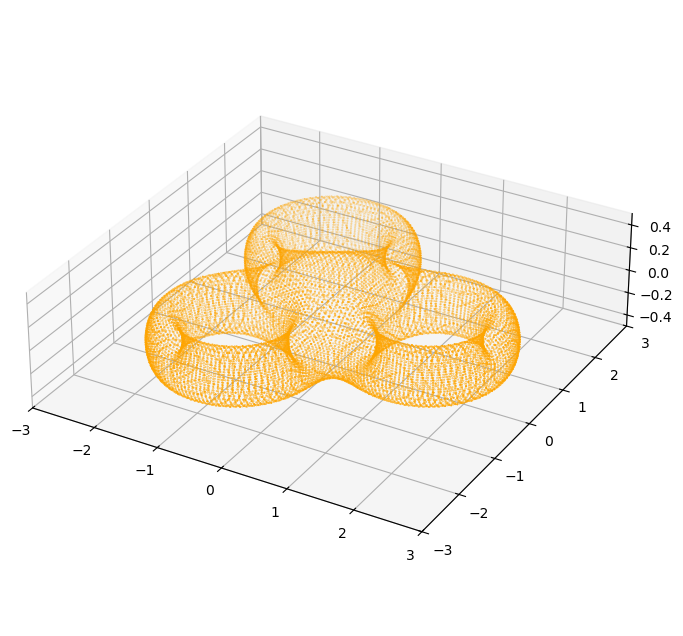

In [4]:
import numpy as np
from skimage.measure import marching_cubes
import matplotlib.pyplot as plt


def torus_implicit(x, y, z, R, r):
    return (x ** 2 + y ** 2 + z ** 2) ** 2 - 2 * (R ** 2 + r ** 2) * (x ** 2 + y ** 2) + 2 * (
                R ** 2 - r ** 2) * z ** 2 + (R ** 2 - r ** 2) ** 2


def genus3_function(x, y, z, n=3):
    f = np.ones_like(x)
    for i in range(n):
        xi = x - 1.5 * np.cos(i * 2 * np.pi / n)
        yi = y - 1.5 * np.sin(i * 2 * np.pi / n)
        zi = z
        f *= torus_implicit(xi, yi, zi, 1, 0.25)
    return f - 10


# Set up the grid
grid_x, grid_y, grid_z = np.mgrid[-3:3:100j, -3:3:100j, -0.5:0.5:50j]

# Evaluate the function
values = genus3_function(grid_x, grid_y, grid_z)

# Extract the surface (isosurface at 0 level)
verts, faces, normals, _ = marching_cubes(values, level=0)

# Get point cloud
points = verts * np.array([(6 / 100), (6 / 100), (1 / 50)]) + np.array([-3, -3, -0.5])

# Plot point cloud
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=0.1, color='orange')

ax.set_box_aspect([1, 1, 0.3])
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_zlim(-0.5, 0.5)
plt.show()

In [2]:


# Example usage:
# points = generate_genus3()